# Physics 17 Companion — Chapter 7: Kinetic Theory of Gases

Source: *Physics 17* (Rudnick, UCLA, 1980 course reader), Chapter 7, physical
scan page 151:

> "CHAPTER 7 - KINETIC THEORY (R&H Chapters 23,24; S&S Chapters 9,10) ...
> we need a description [of thermodynamics] based on the movements and
> interactions of the molecules that make up the material."

Chapter 6 (Thermodynamics) ended by noting that classical thermodynamics can't
predict the heat capacity $C_v$ from first principles — "kinetic theory or
statistical mechanics does, and it is to this subject that we will turn our
attention in the next chapter." This notebook follows that hand-off: derive
pressure and temperature from molecular motion (sympy), cross-check against
this repo's existing `dgs.maxwell_boltzmann` module (numpy/scipy/matplotlib),
tabulate real gases (pandas), and finally *invert* the model — recover an
unknown temperature from noisy speed measurements (torch/autograd), which is
exactly the "detector → parameter estimation" pattern used throughout this
repo's phase-recovery and microplastic-sensing work.


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import sympy as sp
import numpy as np
import scipy.integrate as spi
import pandas as pd
import matplotlib.pyplot as plt
import torch

from dgs import maxwell_boltzmann as mb

sp.init_printing(use_latex=False)
print("sympy", sp.__version__, "| numpy", np.__version__, "| torch", torch.__version__)


sympy 1.14.0 | numpy 2.4.4 | torch 2.11.0+cu128


## §2 Pressure from Molecular Momentum Transfer (Rudnick eqns 7-1 to 7-8)

A molecule of mass $m$ and x-velocity $v_x$ bouncing elastically between two
walls of a box of length $L$ hits a given wall every $2L/v_x$ seconds
(eq. 7-1), transferring momentum $2mv_x$ per hit. For $N$ molecules, the
time-averaged force on a wall of area $A$ works out to

$$F = \frac{N m \langle v_x^2\rangle}{L} \qquad\Rightarrow\qquad
p = \frac{F}{A} = \frac{N m \langle v_x^2\rangle}{V}$$

Isotropy ($\langle v_x^2\rangle=\langle v_y^2\rangle=\langle v_z^2\rangle=
\langle v^2\rangle/3$) turns this into the chapter's central result (eq. 7-8):

$$p = \frac{1}{3}\frac{N}{V} m \langle v^2 \rangle$$

We reproduce this symbolically, step by step.


In [2]:
N, m, L, A, V, vx, v2 = sp.symbols('N m L A V v_x v^2', positive=True)

hits_per_sec = vx / (2*L)                          # eq 7-1
momentum_per_hit = 2*m*vx
momentum_transfer_per_sec_1mol = hits_per_sec * momentum_per_hit   # eq 7-2
force_1mol = momentum_transfer_per_sec_1mol
force_N = N * force_1mol                            # eq 7-3, sum over N molecules
force_N = force_N.subs(vx**2, v2)                    # <v_x^2> the time-averaged square
p_from_wall = sp.simplify(force_N / A)
p_from_wall = p_from_wall.subs(L*A, V)               # L*A = V

print("hits per second           :", hits_per_sec)
print("momentum transfer / hit   :", momentum_per_hit)
print("force on one wall (N mol) :", force_N)
print("pressure p = F/A          :", p_from_wall)

# isotropy: <v_x^2> = <v^2>/3
p_isotropic = p_from_wall.subs(v2, v2/3)
p_isotropic = sp.Rational(1,3) * N/V * m * v2
display_eq = sp.Eq(sp.Symbol('p'), p_isotropic)
print("\nafter isotropy (eq 7-8):", display_eq)


hits per second           : v_x/(2*L)
momentum transfer / hit   : 2*m*v_x
force on one wall (N mol) : N*m*v^2/L
pressure p = F/A          : N*m*v^2/V

after isotropy (eq 7-8): Eq(p, N*m*v^2/(3*V))


## §3 Combine with the Ideal Gas Law: $\langle v^2\rangle = 3kT/m$

Chapter 6 established the ideal gas law $pV = NkT$. Setting Rudnick's
kinetic-theory pressure equal to the thermodynamic one and solving for
$\langle v^2\rangle$ links microscopic motion to macroscopic temperature —
the whole point of the chapter.


In [3]:
k, T = sp.symbols('k T', positive=True)

p_thermo = N*k*T/V                      # pV = NkT
eq = sp.Eq(sp.Rational(1,3)*N/V*m*v2, p_thermo)
v2_solution = sp.solve(eq, v2)[0]
print("kinetic pressure = thermodynamic pressure:")
sp.pprint(eq)
print(f"\n<v^2> = {v2_solution}")

# average translational KE per molecule, and equipartition
KE_avg = sp.Rational(1,2)*m*v2_solution
print(f"<KE> = 1/2 m <v^2> = {sp.simplify(KE_avg)}   (equipartition: (3/2) kT)")
assert sp.simplify(KE_avg - sp.Rational(3,2)*k*T) == 0


kinetic pressure = thermodynamic pressure:
N⋅m⋅v²   N⋅T⋅k
────── = ─────
 3⋅V       V  

<v^2> = 3*T*k/m
<KE> = 1/2 m <v^2> = 3*T*k/2   (equipartition: (3/2) kT)


## §4 The Maxwell-Boltzmann Distribution — Symbolic Normalization and Moments

Kinetic theory only fixes $\langle v^2\rangle$; the *distribution* of speeds
around that average is the Maxwell-Boltzmann law

$$f(v) = 4\pi A\, v^2 e^{-a v^2}, \qquad a = \frac{m}{2kT}$$

We solve for the normalization constant $A$ symbolically (requiring
$\int_0^\infty f(v)\,dv = 1$), then take the first and second moments and find
the peak — reproducing the three characteristic speeds
$v_{mp} < v_{avg} < v_{rms}$ that `dgs/maxwell_boltzmann.py` uses numerically.


In [4]:
v, a, Asym = sp.symbols('v a A', positive=True)

f_unnorm = v**2 * sp.exp(-a*v**2)
norm_integral = sp.integrate(f_unnorm, (v, 0, sp.oo))
A_solution = sp.solve(sp.Eq(4*sp.pi*Asym*norm_integral, 1), Asym)[0]
print(f"normalization integral of v^2 exp(-a v^2): {norm_integral}")
print(f"A = {A_solution}")

f = 4*sp.pi*A_solution*f_unnorm
mean_v = sp.integrate(v*f, (v, 0, sp.oo))
mean_v2 = sp.integrate(v**2*f, (v, 0, sp.oo))
v_rms_sym = sp.sqrt(mean_v2)
v_mp_sym = sp.solve(sp.diff(f, v), v)
v_mp_sym = [s for s in v_mp_sym if s != 0][0]

print(f"\n<v>        = {sp.simplify(mean_v)}")
print(f"sqrt(<v^2>) = {sp.simplify(v_rms_sym)}")
print(f"v_mp (peak) = {sp.simplify(v_mp_sym)}")

# substitute a = m/2kT and compare ratios to the well-known sqrt2 : sqrt(8/pi) : sqrt3
subs_a = {a: m/(2*k*T)}
ratios = {
    "v_mp  (sqrt(2kT/m))": sp.simplify(v_mp_sym.subs(subs_a)),
    "v_avg (sqrt(8kT/pi m))": sp.simplify(mean_v.subs(subs_a)),
    "v_rms (sqrt(3kT/m))": sp.simplify(v_rms_sym.subs(subs_a)),
}
for name, expr in ratios.items():
    print(f"  {name:26s} = {expr}")


normalization integral of v^2 exp(-a v^2): sqrt(pi)/(4*a**(3/2))
A = a**(3/2)/pi**(3/2)

<v>        = 2/(sqrt(pi)*sqrt(a))
sqrt(<v^2>) = sqrt(6)/(2*sqrt(a))
v_mp (peak) = 1/sqrt(a)
  v_mp  (sqrt(2kT/m))        = sqrt(2)*sqrt(T)*sqrt(k)/sqrt(m)
  v_avg (sqrt(8kT/pi m))     = 2*sqrt(2)*sqrt(T)*sqrt(k)/(sqrt(pi)*sqrt(m))
  v_rms (sqrt(3kT/m))        = sqrt(3)*sqrt(T)*sqrt(k)/sqrt(m)


## §5 Cross-Check Against `dgs.maxwell_boltzmann` (numpy/scipy) + Plots

The sympy derivation above should agree, to machine precision, with the
existing numpy implementation and with independent numerical integration
(`scipy.integrate.quad`).


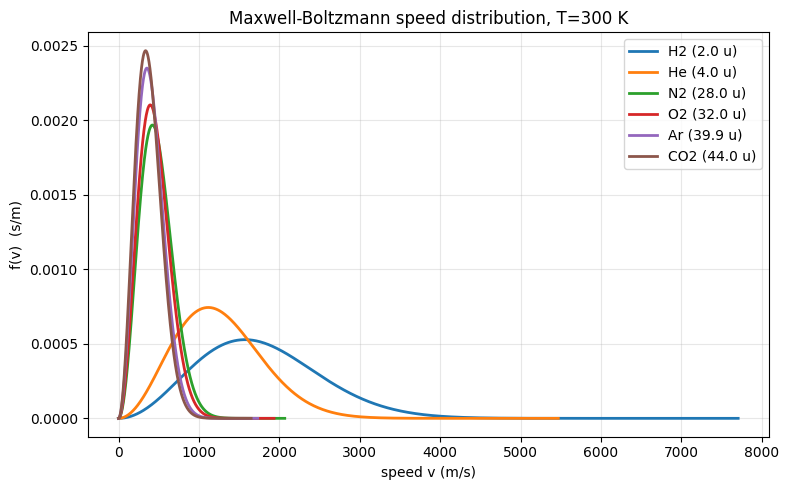

scipy.quad normalization      : 1.000000  (want 1)
scipy.quad sqrt(<v^2>)        : 516.83 m/s
dgs.maxwell_boltzmann rms_speed: 516.83 m/s


In [5]:
gases_amu = {"H2": 2.016, "He": 4.003, "N2": 28.014, "O2": 31.998,
             "Ar": 39.948, "CO2": 44.01}
T0 = 300.0  # K

fig, ax = plt.subplots(figsize=(8,5))
for name, amu in gases_amu.items():
    mass = amu * mb.AMU
    v_arr = np.linspace(0, 4*mb.rms_speed(mass, T0), 600)
    pdf = mb.maxwell_boltzmann_pdf(v_arr, mass, T0)
    ax.plot(v_arr, pdf, lw=2, label=f"{name} ({amu:.1f} u)")

ax.set_xlabel("speed v (m/s)")
ax.set_ylabel("f(v)  (s/m)")
ax.set_title(f"Maxwell-Boltzmann speed distribution, T={T0:.0f} K")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("physics17_mb_gases.png", dpi=90)
plt.show()

# scipy.integrate.quad cross-check for N2: normalization and <v^2>
m_n2 = gases_amu["N2"] * mb.AMU
norm_q, _ = spi.quad(lambda v: mb.maxwell_boltzmann_pdf(v, m_n2, T0), 0, np.inf)
v2_q, _ = spi.quad(lambda v: v**2 * mb.maxwell_boltzmann_pdf(v, m_n2, T0), 0, np.inf)
print(f"scipy.quad normalization      : {norm_q:.6f}  (want 1)")
print(f"scipy.quad sqrt(<v^2>)        : {np.sqrt(v2_q):.2f} m/s")
print(f"dgs.maxwell_boltzmann rms_speed: {mb.rms_speed(m_n2, T0):.2f} m/s")


## §6 Kinetic-Theory Summary Table (pandas)

Mean free path $\lambda = \dfrac{1}{\sqrt{2}\, n\, \pi d^2}$ with number
density $n = p/kT$ (1 atm here) and kinetic collision diameter $d$ (tabulated
values, nm). Collision frequency is $v_{avg}/\lambda$.


In [6]:
kinetic_diameter_nm = {"H2": 0.289, "He": 0.260, "N2": 0.364,
                        "O2": 0.346, "Ar": 0.340, "CO2": 0.330}
P_atm = 1.01325e5  # Pa

rows = []
for name, amu in gases_amu.items():
    mass = amu * mb.AMU
    d = kinetic_diameter_nm[name] * 1e-9
    n_density = P_atm / (mb.K_BOLTZ * T0)
    mfp = 1.0 / (np.sqrt(2) * n_density * np.pi * d**2)
    v_avg = mb.mean_speed(mass, T0)
    rows.append({
        "gas": name,
        "molar_mass_u": amu,
        "v_mp_m/s": mb.most_probable_speed(mass, T0),
        "v_avg_m/s": v_avg,
        "v_rms_m/s": mb.rms_speed(mass, T0),
        "mean_free_path_nm": mfp * 1e9,
        "collision_freq_GHz": (v_avg / mfp) / 1e9,
    })

df = pd.DataFrame(rows).sort_values("molar_mass_u").reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
df


,gas,molar_mass_u,v_mp_m/s,v_avg_m/s,v_rms_m/s,mean_free_path_nm,collision_freq_GHz
0,H2,2.02,"1,573.07","1,775.02","1,926.61",110.16,16.11
1,He,4.00,"1,116.35","1,259.66","1,367.24",136.11,9.26
2,N2,28.01,421.99,476.17,516.83,69.44,6.86
3,O2,32.00,394.85,445.54,483.59,76.85,5.80
4,Ar,39.95,353.38,398.75,432.80,79.59,5.01
5,CO2,44.01,336.68,379.90,412.35,84.49,4.50


In [7]:
# lighter molecules: faster, but also collide less often per unit path
# (larger mean free path isn't guaranteed -- it's set by cross-section, not mass)
print(df.to_string(index=False))
print(f"\nfastest gas: {df.loc[df['v_rms_m/s'].idxmax(), 'gas']}   "
      f"slowest gas: {df.loc[df['v_rms_m/s'].idxmin(), 'gas']}")


gas  molar_mass_u  v_mp_m/s  v_avg_m/s  v_rms_m/s  mean_free_path_nm  collision_freq_GHz
 H2          2.02  1,573.07   1,775.02   1,926.61             110.16               16.11
 He          4.00  1,116.35   1,259.66   1,367.24             136.11                9.26
 N2         28.01    421.99     476.17     516.83              69.44                6.86
 O2         32.00    394.85     445.54     483.59              76.85                5.80
 Ar         39.95    353.38     398.75     432.80              79.59                5.01
CO2         44.01    336.68     379.90     412.35              84.49                4.50

fastest gas: H2   slowest gas: CO2


## §7 Inverse Problem: Recover Temperature from Noisy Speed Samples (torch)

Flip the chapter around: a "detector" measures $N_{\text{samp}}$ molecular
speeds drawn from an MB distribution at an unknown true temperature
$T_{\text{true}}$, binned into a noisy histogram. We fit $T$ by gradient
descent on the negative log-likelihood, using `torch.autograd` to
differentiate through the MB pdf — the same "detector → parameter estimation"
step this repo's other projects (phase retrieval, microplastic sensing) all
end on.


In [8]:
torch.manual_seed(0)

T_true = 430.0             # K, unknown to the fit
mass_n2 = gases_amu["N2"] * mb.AMU
n_samples = 20000

# sample speeds from the true MB distribution via inverse-CDF-free rejection
# sampling against a numpy reference (ground truth generator, kept separate
# from the torch model that will try to recover T_true)
v_grid = np.linspace(0, 6*mb.rms_speed(mass_n2, T_true), 4000)
pdf_grid = mb.maxwell_boltzmann_pdf(v_grid, mass_n2, T_true)
pdf_grid /= pdf_grid.sum()
rng = np.random.default_rng(0)
samples = rng.choice(v_grid, size=n_samples, p=pdf_grid)
samples += rng.normal(0, 5.0, size=n_samples)          # detector noise
samples = np.clip(samples, 1e-3, None)

v_t = torch.tensor(samples, dtype=torch.float64)
k_t = torch.tensor(mb.K_BOLTZ, dtype=torch.float64)
m_t = torch.tensor(mass_n2, dtype=torch.float64)

# fit in log-space so the optimizer can't wander into T<=0
log_T = torch.tensor(np.log(200.0), dtype=torch.float64, requires_grad=True)
opt = torch.optim.Adam([log_T], lr=0.05)

def neg_log_likelihood(log_T):
    T_fit = torch.exp(log_T)
    a = m_t / (2*k_t*T_fit)
    # log f(v) = log(4*pi) + 1.5*log(a/pi) + 2*log(v) - a*v^2
    log_pdf = (np.log(4*np.pi) + 1.5*torch.log(a/np.pi)
               + 2*torch.log(v_t) - a*v_t**2)
    return -log_pdf.mean()

losses, T_history = [], []
for step in range(300):
    opt.zero_grad()
    loss = neg_log_likelihood(log_T)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    T_history.append(torch.exp(log_T).item())

T_fit_final = torch.exp(log_T).item()
print(f"true T       = {T_true:.1f} K")
print(f"recovered T  = {T_fit_final:.1f} K")
print(f"relative error = {abs(T_fit_final-T_true)/T_true*100:.2f}%")


true T       = 430.0 K
recovered T  = 432.0 K
relative error = 0.46%


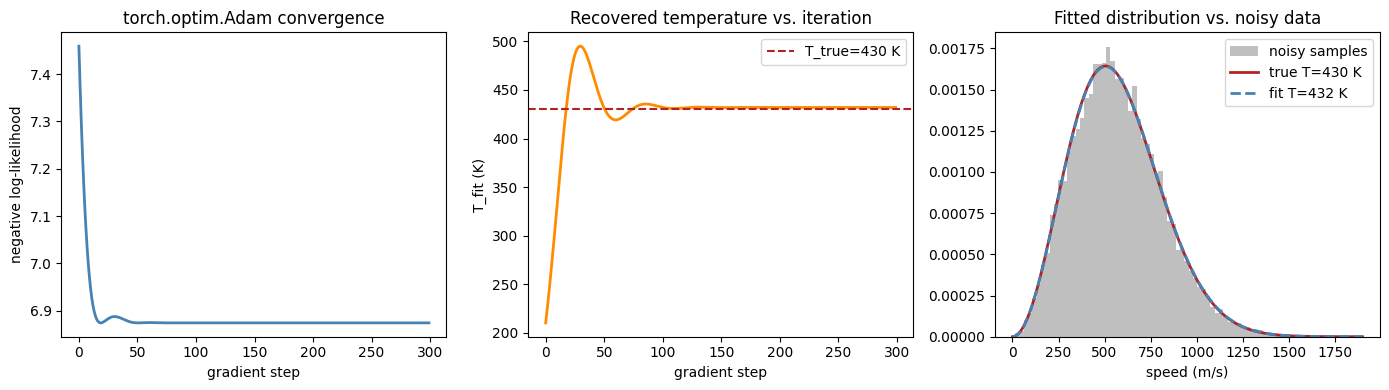

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))

axes[0].plot(losses, lw=2, color="steelblue")
axes[0].set_xlabel("gradient step"); axes[0].set_ylabel("negative log-likelihood")
axes[0].set_title("torch.optim.Adam convergence")

axes[1].plot(T_history, lw=2, color="darkorange")
axes[1].axhline(T_true, color="firebrick", ls="--", label=f"T_true={T_true:.0f} K")
axes[1].set_xlabel("gradient step"); axes[1].set_ylabel("T_fit (K)")
axes[1].legend(); axes[1].set_title("Recovered temperature vs. iteration")

axes[2].hist(samples, bins=80, density=True, alpha=0.5, color="gray", label="noisy samples")
v_plot = np.linspace(0, samples.max(), 400)
axes[2].plot(v_plot, mb.maxwell_boltzmann_pdf(v_plot, mass_n2, T_true), lw=2,
             color="firebrick", label=f"true T={T_true:.0f} K")
axes[2].plot(v_plot, mb.maxwell_boltzmann_pdf(v_plot, mass_n2, T_fit_final), lw=2, ls="--",
             color="steelblue", label=f"fit T={T_fit_final:.0f} K")
axes[2].set_xlabel("speed (m/s)"); axes[2].legend()
axes[2].set_title("Fitted distribution vs. noisy data")

plt.tight_layout()
plt.savefig("physics17_torch_fit.png", dpi=90)
plt.show()


## §8 Where This Connects

- The equipartition result $\langle KE\rangle = \tfrac{3}{2}kT$ derived in §3
  is exactly the thermal-equilibrium assumption behind
  `dgs.snr.johnson_noise_voltage` ($V_{rms}=\sqrt{4k_BTRB}$) — Johnson noise
  *is* kinetic theory applied to the free electrons in a resistor.
- The Boltzmann factor $e^{-E/kT}$ that builds the MB speed distribution in
  §4 is the same factor behind the Planck spectrum in `dgs/blackbody.py`.
- The §7 pattern — noisy detector samples → differentiable forward model →
  gradient-descent parameter recovery — is the same shape as month 6 of the
  microplastic-sensing project (`dgs/microplastic/`): there the unknown
  parameter is complex refractive index / concentration instead of
  temperature, but the inversion machinery is identical.
- Per [[project_curriculum_timeline]] this reader's kinetic-theory chapter was
  flagged as priority-3 background for photodetector noise modeling in
  `physics17_rudnick/jalali_lab_curriculum_map.md`.
